In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Построим регрессию новостей на изменения с лагом в 3 дня
#### Отберем только только не nan значения в Full_news и не nan значения в Изменениях с лагом

In [54]:
df = pd.read_csv('final_df.csv')

In [56]:
df = df[['Date', 'filtered_text', 'Company', 'Изменение с лагом в 3 дня %', 'Изменение с лагом в 2 дня %', 'Изменение с лагом в 1 день %']].copy()
df.dropna(inplace = True)
df

,Date,filtered_text,Company,Изменение с лагом в 3 дня %,Изменение с лагом в 2 дня %,Изменение с лагом в 1 день %
3,2024-12-19,выплатить доход также выплата причитаться влад...,magnit,11.335699,12.111170,10.849228
7,2024-12-13,включение организатор торговля список допустит...,magnit,0.486234,-1.622707,-2.351161
8,2024-12-12,завершение размещение некоммерческий магнит ед...,magnit,-2.345548,-3.074001,-0.722840
17,2024-11-29,отдельный решение принять совет директор наблю...,magnit,53.630679,47.025197,44.694480
22,2024-11-22,определяться фиксироваться иметь право осущест...,magnit,-6.456819,-7.963484,-3.717563
...,...,...,...,...,...,...
6831,2018-01-17,направлять предоставлять соответствовать иност...,lukoil,0.479182,-0.677351,0.090832
6833,2018-01-15,направлять предоставлять соответствовать иност...,lukoil,-0.556168,-0.647000,-0.374750
6834,2018-01-11,направлять предоставлять соответствовать иност...,lukoil,-24.829518,-24.557268,-24.182517
6837,2018-01-06,направлять предоставлять соответствовать иност...,lukoil,16.036467,17.623961,6.634998


#### Признаки - full_news

In [5]:
X = df['filtered_text']

#### Целевая переменная - Изменение с лагом в 3 дня %

In [6]:
y = df['Изменение с лагом в 3 дня %']

### Разбиение на тренировочный и тестовый наборы

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
tf_idf = TfidfVectorizer()

In [12]:
tf_idf.fit(X_train)

TfidfVectorizer()

In [13]:
X_train = tf_idf.transform(X_train)

In [14]:
X_test = tf_idf.transform(X_test)

# Модель CatBoost

In [15]:
from catboost import CatBoostRegressor

In [34]:
cat_boost = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6)
cat_boost.fit(X_train, y_train)

0:	learn: 15.8143234	total: 198ms	remaining: 3m 18s
1:	learn: 15.7980600	total: 372ms	remaining: 3m 5s
2:	learn: 15.7761212	total: 551ms	remaining: 3m 3s
3:	learn: 15.7359678	total: 727ms	remaining: 3m 1s
4:	learn: 15.7194494	total: 908ms	remaining: 3m
5:	learn: 15.6868677	total: 1.08s	remaining: 2m 59s
6:	learn: 15.6340842	total: 1.27s	remaining: 3m
7:	learn: 15.6053138	total: 1.45s	remaining: 2m 59s
8:	learn: 15.5863558	total: 1.63s	remaining: 2m 59s
9:	learn: 15.5645496	total: 1.8s	remaining: 2m 58s
10:	learn: 15.5461438	total: 1.98s	remaining: 2m 57s
11:	learn: 15.5338417	total: 2.15s	remaining: 2m 57s
12:	learn: 15.5197718	total: 2.33s	remaining: 2m 56s
13:	learn: 15.5063040	total: 2.5s	remaining: 2m 56s
14:	learn: 15.4929376	total: 2.68s	remaining: 2m 56s
15:	learn: 15.4149114	total: 2.86s	remaining: 2m 55s
16:	learn: 15.4013356	total: 3.04s	remaining: 2m 55s
17:	learn: 15.3876971	total: 3.21s	remaining: 2m 55s
18:	learn: 15.3648563	total: 3.38s	remaining: 2m 54s
19:	learn: 15.35

In [40]:
y_pred_cat = cat_boost.predict(X_test)

### Результаты работы CatBoost

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [42]:
MAE_cat = mean_absolute_error(y_test, y_pred_cat)
MAE_cat

10.498228294656979

In [43]:
MSE_cat = mean_squared_error(y_test, y_pred_cat)
MSE_cat

242.63106995146694

In [44]:
RMSE_cat = np.sqrt(MSE_cat)
RMSE_cat

15.576619336411445

### Визуализация

In [60]:
df.head()

,Date,filtered_text,Company,Изменение с лагом в 3 дня %,Изменение с лагом в 2 дня %,Изменение с лагом в 1 день %
3,2024-12-19,выплатить доход также выплата причитаться влад...,magnit,11.335699,12.111170,10.849228
7,2024-12-13,включение организатор торговля список допустит...,magnit,0.486234,-1.622707,-2.351161
8,2024-12-12,завершение размещение некоммерческий магнит ед...,magnit,-2.345548,-3.074001,-0.722840
17,2024-11-29,отдельный решение принять совет директор наблю...,magnit,53.630679,47.025197,44.694480
22,2024-11-22,определяться фиксироваться иметь право осущест...,magnit,-6.456819,-7.963484,-3.717563


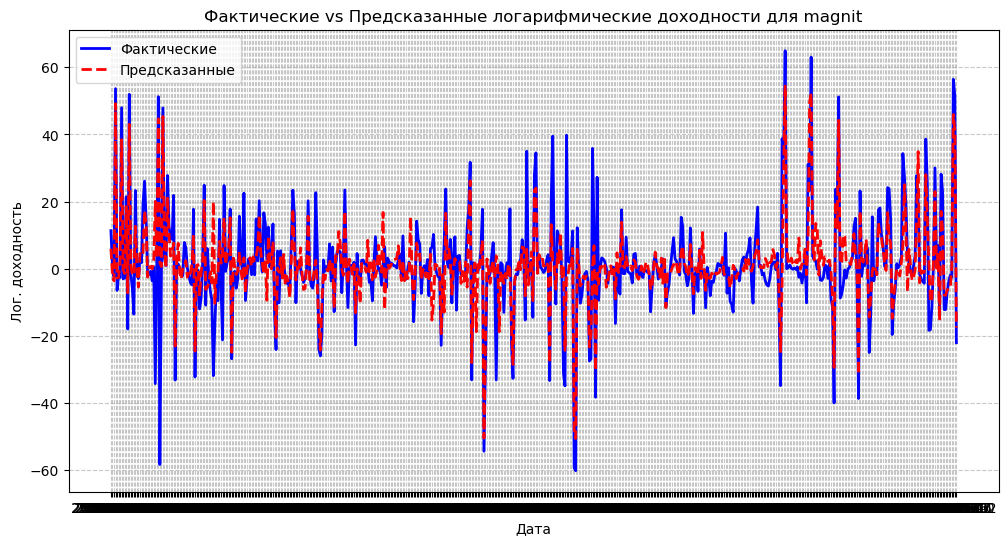

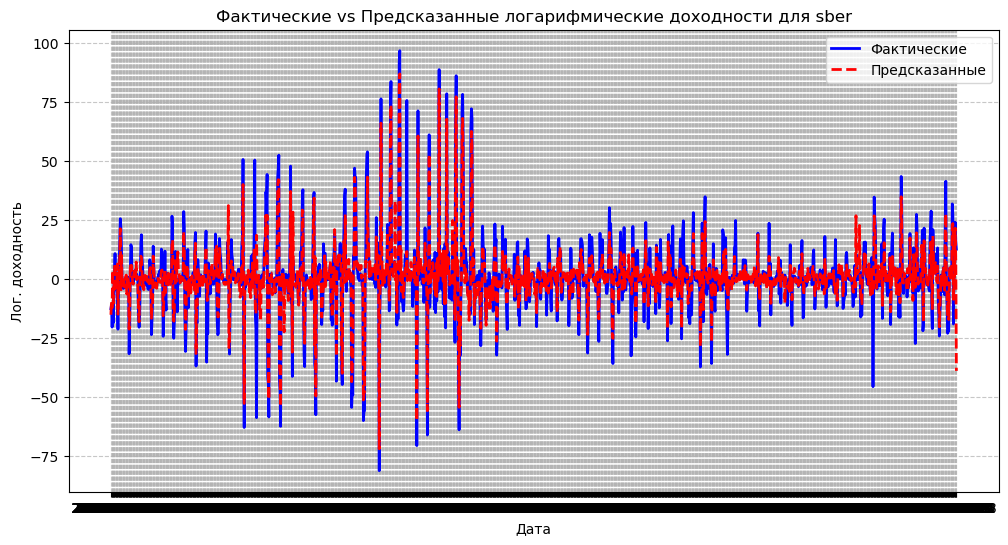

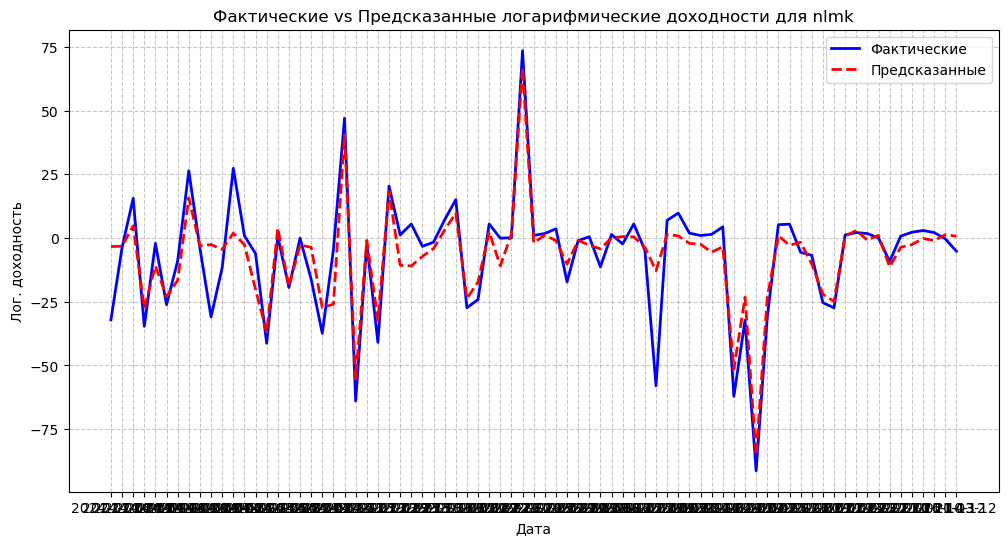

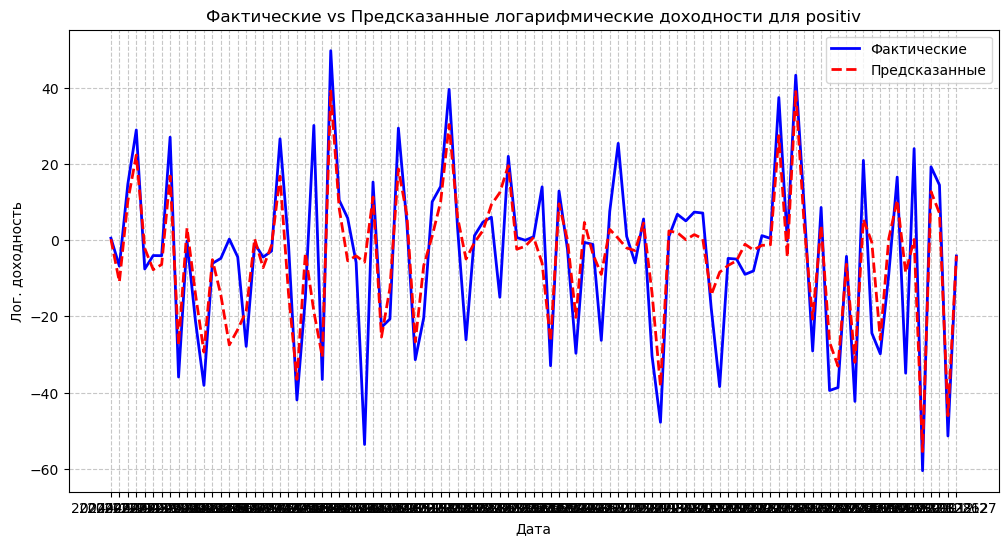

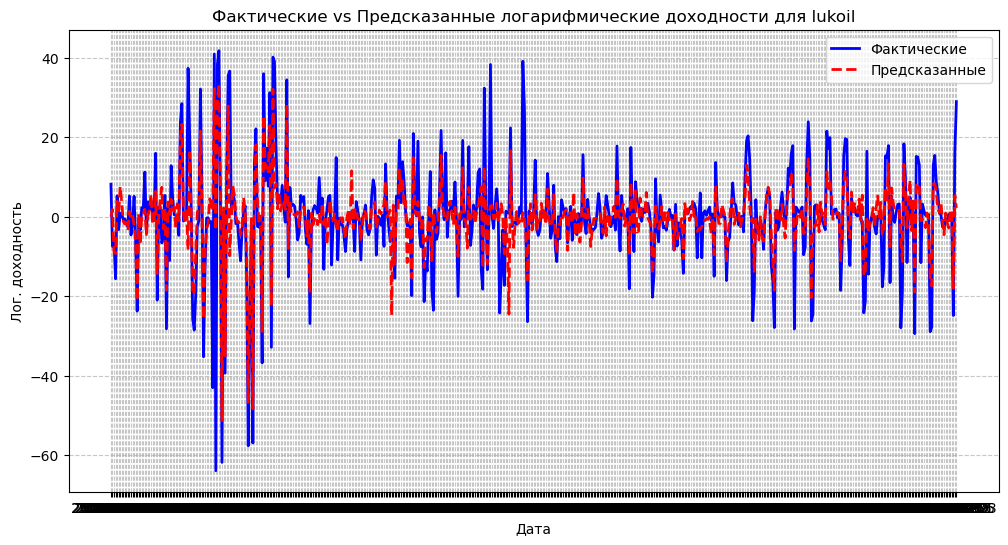

In [65]:
import matplotlib.pyplot as plt
for company in df['Company'].unique():    
    company_df = df[df['Company'] == f'{company}'].copy()
    X_company = tf_idf.transform(company_df['filtered_text'])
    y_company = company_df['Изменение с лагом в 3 дня %']
    y_pred_company = cat_boost.predict(X_company)
    date_company = company_df['Date']

    plt.figure(figsize=(12, 6))
    plt.plot(date_company, y_company, label= f"Фактические", color="blue", linewidth=2)
    plt.plot(date_company, y_pred_company, label= f"Предсказанные", color="red", linestyle="--", linewidth=2)
    plt.title(f"Фактические vs Предсказанные логарифмические доходности для {company}")
    plt.xlabel("Дата")
    plt.ylabel("Лог. доходность")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

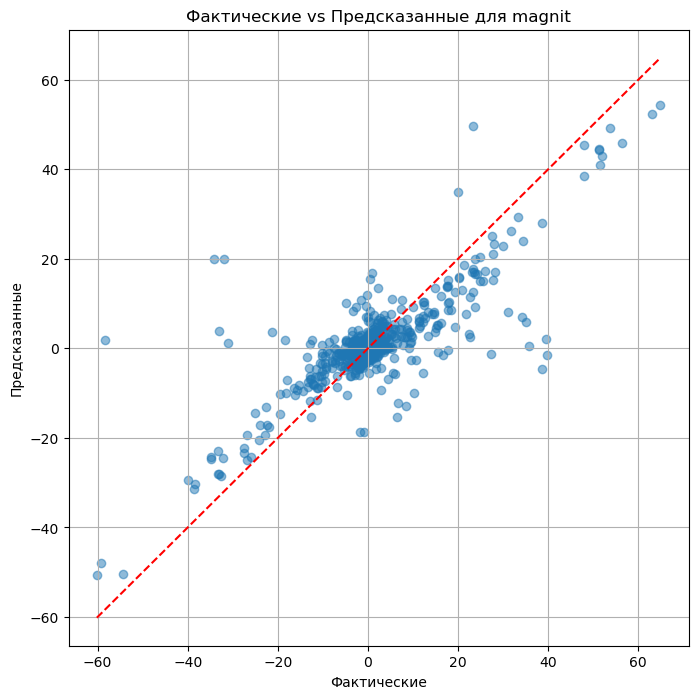

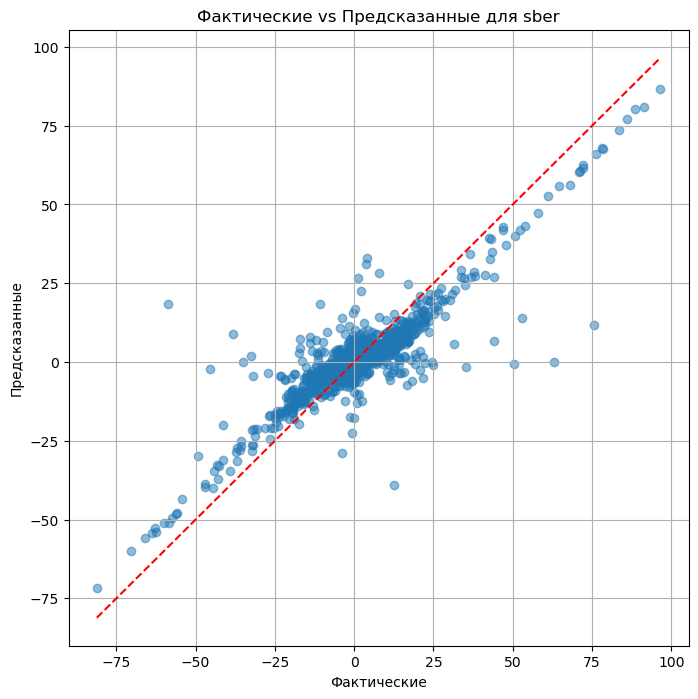

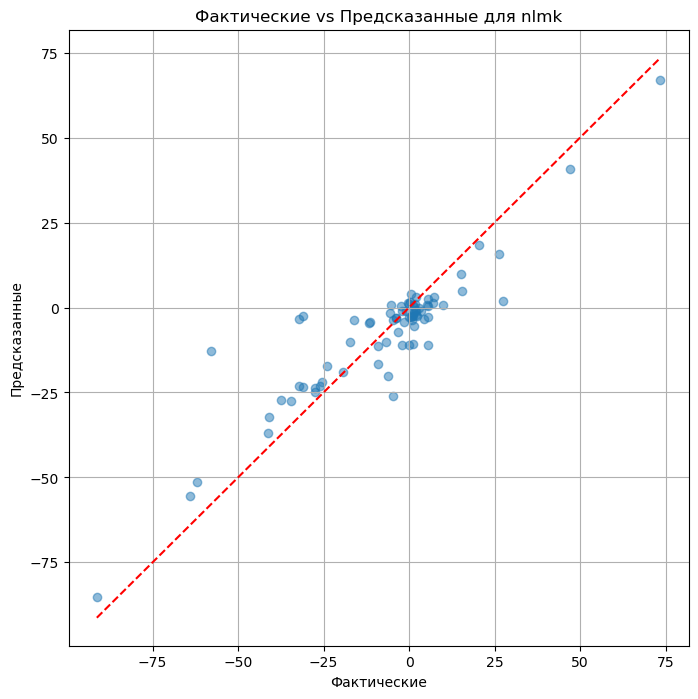

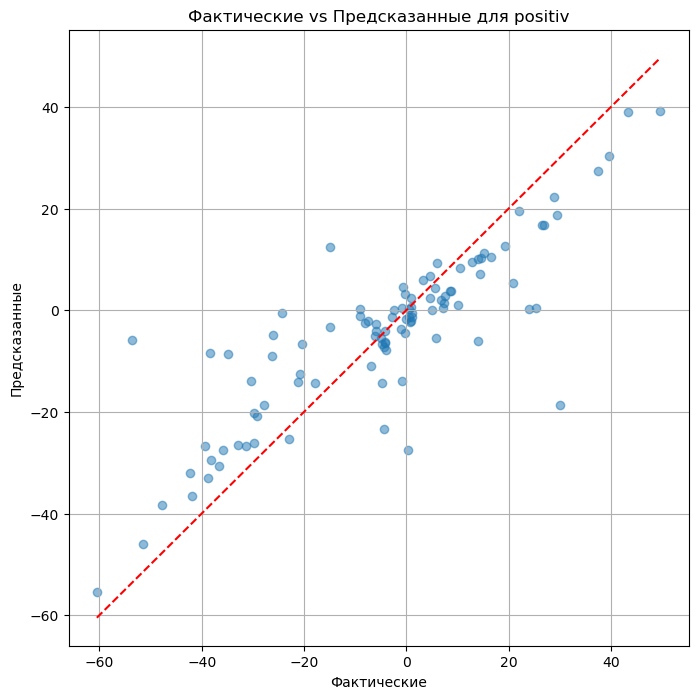

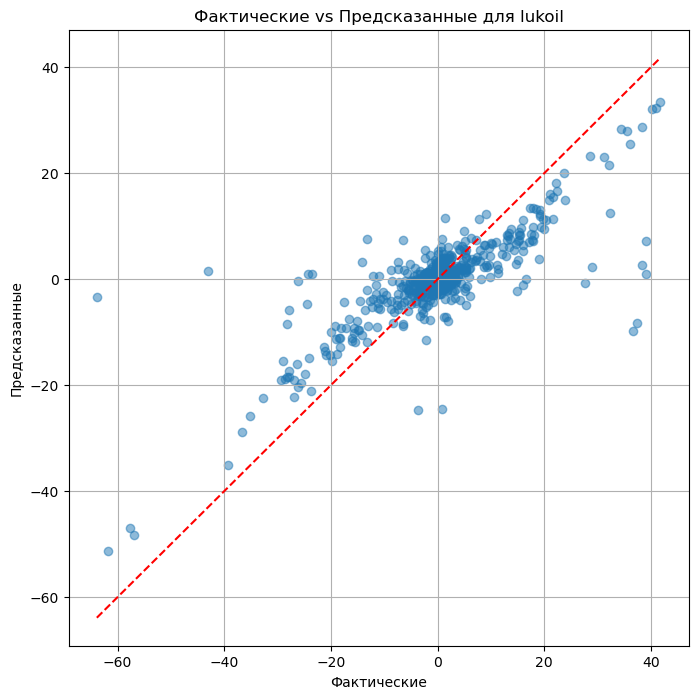

In [70]:
import matplotlib.pyplot as plt
for company in df['Company'].unique():    
    company_df = df[df['Company'] == f'{company}'].copy()
    X_company = tf_idf.transform(company_df['filtered_text'])
    y_company = company_df['Изменение с лагом в 3 дня %']
    y_pred_company = cat_boost.predict(X_company)
    date_company = company_df['Date']

    plt.figure(figsize=(8, 8))
    plt.scatter(y_company, y_pred_company, alpha=0.5)
    plt.plot([min(y_company), max(y_company)], [min(y_company), max(y_company)], color="red", linestyle="--")  # Идеальная линия
    plt.xlabel("Фактические")
    plt.ylabel("Предсказанные")
    plt.title(f"Фактические vs Предсказанные для {company}")
    plt.grid(True)
    plt.show()

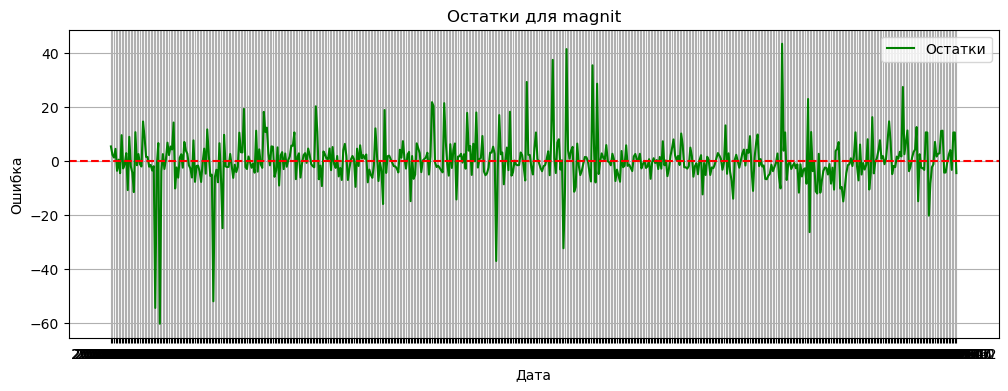

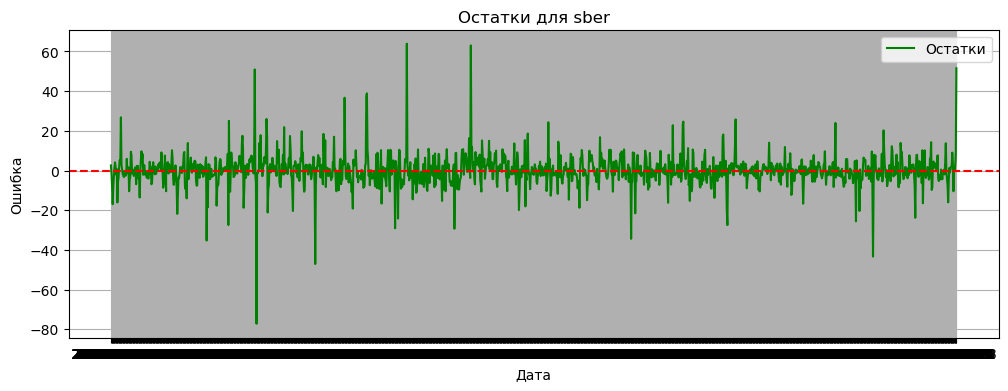

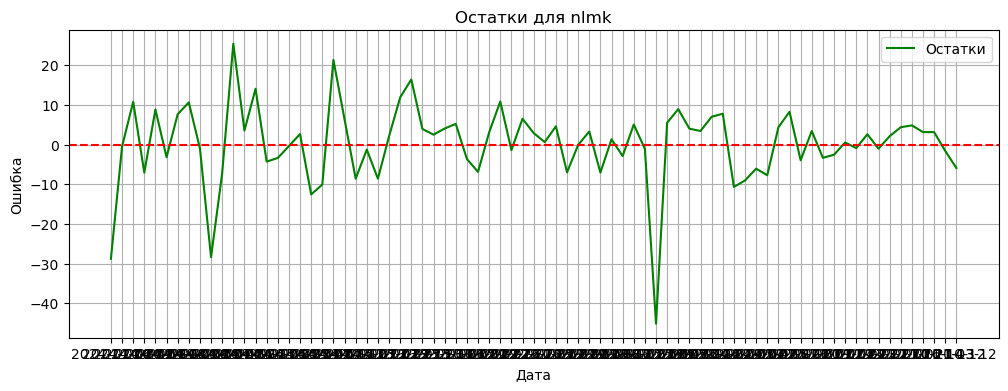

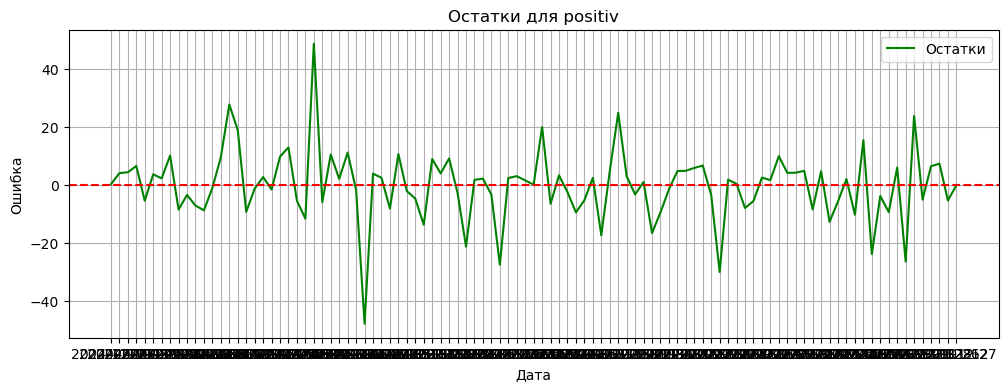

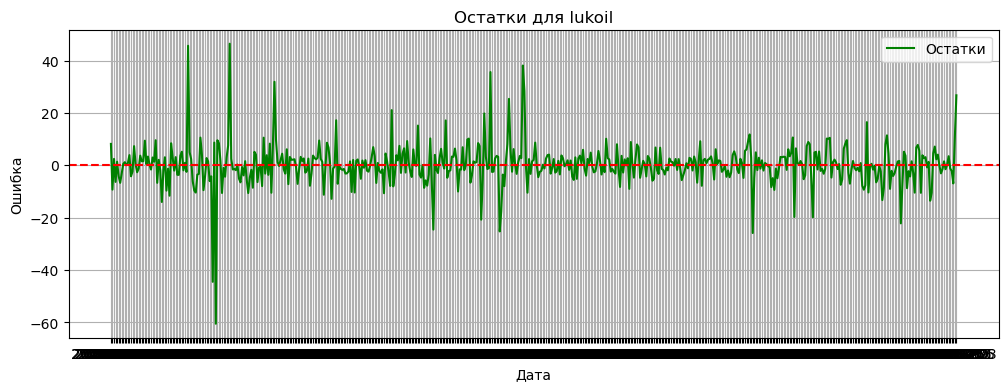

In [69]:
import matplotlib.pyplot as plt
for company in df['Company'].unique():    
    company_df = df[df['Company'] == f'{company}'].copy()
    X_company = tf_idf.transform(company_df['filtered_text'])
    y_company = company_df['Изменение с лагом в 3 дня %']
    y_pred_company = cat_boost.predict(X_company)
    date_company = company_df['Date']

    residuals = y_company - y_pred_company
    plt.figure(figsize=(12, 4))
    plt.plot(date_company, residuals, color="green", label="Остатки")
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Остатки для {company}")
    plt.xlabel("Дата")
    plt.ylabel("Ошибка")
    plt.legend()
    plt.grid(True)
    plt.show()
